In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-dataset/heart.csv


In [2]:
# Decision Trees and Random Forests for Heart Disease Prediction

# Objective: Classification using tree-based models
# Tools: Scikit-learn, Graphviz

# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import graphviz

# 2. Load dataset
# Replace with the actual path to your file
df = pd.read_csv("/kaggle/input/heart-disease-dataset/heart.csv")

# 3. Inspect and preprocess data
print("Dataset shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

# Optional: convert columns to categorical
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 4. Define features and target
X = df.drop('target', axis=1)  # assuming 'target' is the column
y = df['target']

# 5. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# 7. Predict and evaluate
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

# 8. Visualize Decision Tree
dot_data = export_graphviz(dt_model, out_file=None, 
                           feature_names=X.columns,
                           class_names=['No Disease', 'Disease'], 
                           filled=True, rounded=True, 
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")
graph

# 9. Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 10. Predict and evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Dataset shape: (1025, 14)
Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Decision Tree Accuracy: 0.8
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205

Confusion Matrix:
 [[71 31]
 [10 93]]
Random Forest Accuracy: 0.9853658536585366
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99   

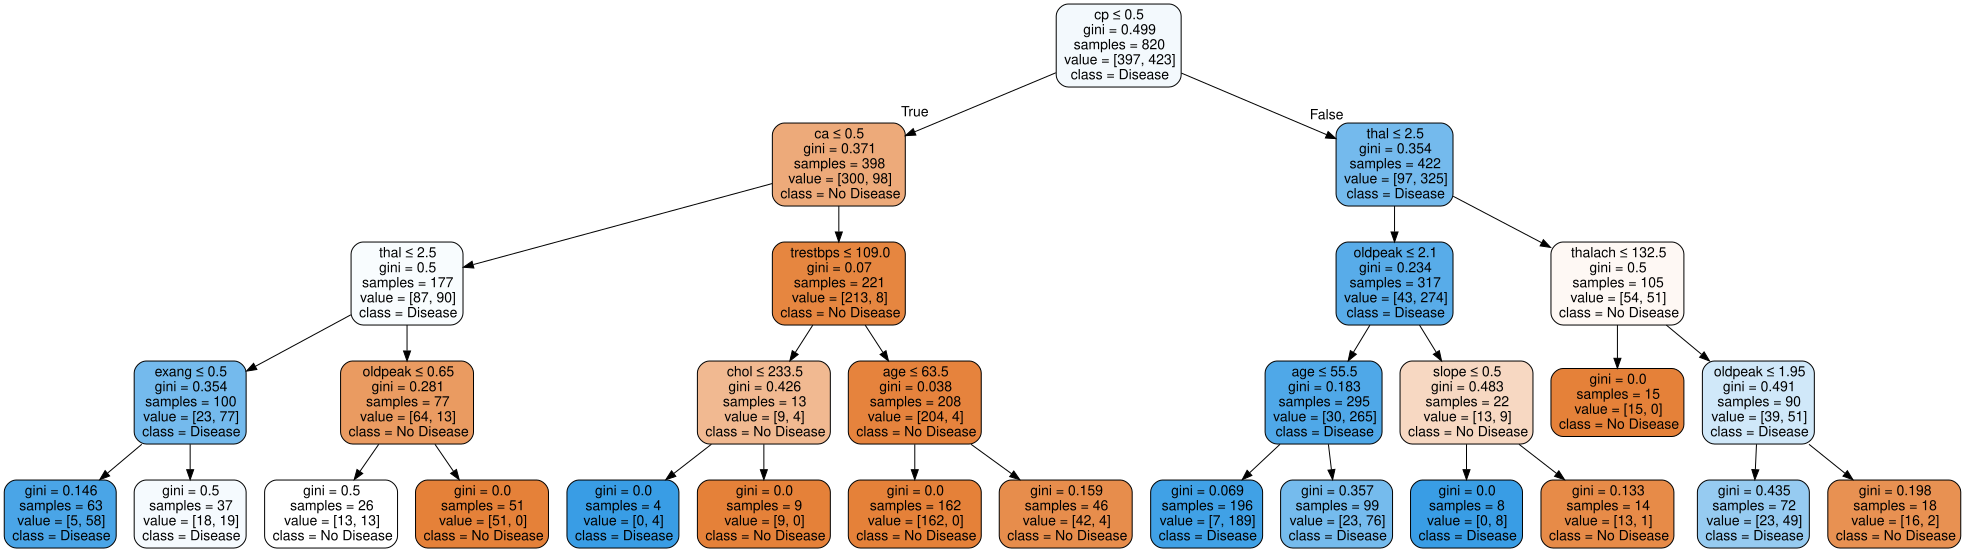

In [3]:
from sklearn.tree import export_graphviz
import graphviz

# Export the decision tree to DOT format
dot_data = export_graphviz(dt_model, out_file=None, 
                           feature_names=X.columns,
                           class_names=['No Disease', 'Disease'], 
                           filled=True, rounded=True, 
                           special_characters=True)

# Display the decision tree using Graphviz
graph = graphviz.Source(dot_data)
graph.render("decision_tree", format='png', cleanup=False)  # saves to file
graph  # this line renders the tree in the notebook


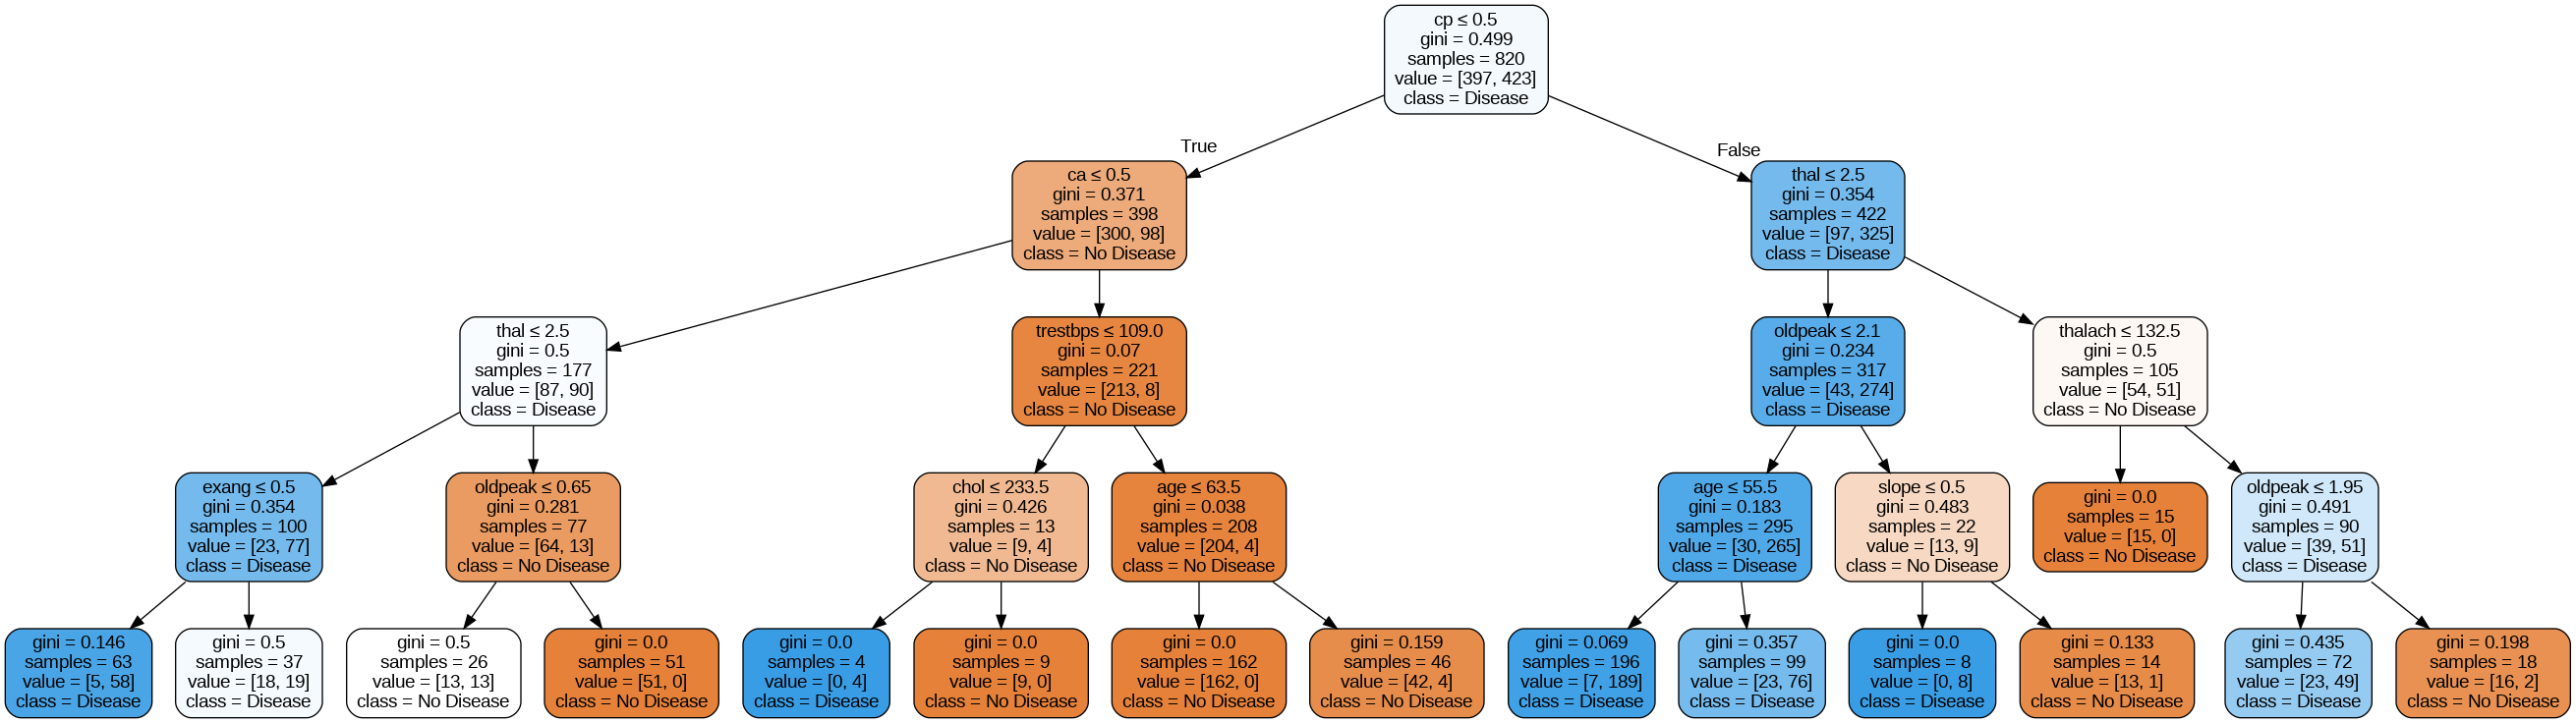

In [4]:
from IPython.display import Image
Image(filename="decision_tree.png")
